In [1]:
import numpy as np
import matplotlib.pyplot as plt
import keras


### Load Model

In [2]:
model = keras.models.load_model("convnet_from_scratch_with_augmentation_50-Epochs.keras")
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 7, 7, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,707,269 (17.96 MB)

 Trainable params: 1,569,089 (5.99 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,138,180 (11.97 MB)

### Get New data

In [3]:
img_path = keras.utils.get_file(fname="cat.jpg", origin="https://img-datasets.s3.amazonaws.com/cat.jpg")

def get_img_array(img_path, target_size):
    img = keras.utils.load_img(img_path, target_size=target_size)
    array = keras.utils.img_to_array(img)
    array = np.expand_dims(array, axis=0)
    return array

img_tensor = get_img_array(img_path, target_size=(180, 180))

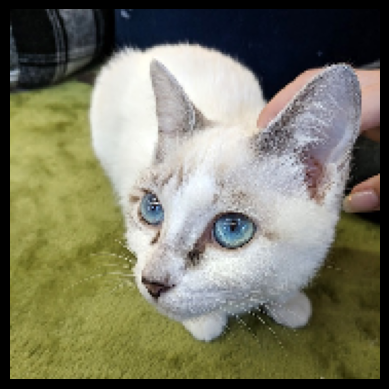

In [4]:
plt.axis("off")
plt.imshow(img_tensor[0].astype("uint8"))
plt.show()

### Model Activations

In [5]:
layer_outputs = []
layer_names = []

In [6]:
model.layers

[<InputLayer name=input_layer_1, built=True>,
 <Rescaling name=rescaling_1, built=True>,
 <Conv2D name=conv2d_5, built=True>,
 <MaxPooling2D name=max_pooling2d_4, built=True>,
 <Conv2D name=conv2d_6, built=True>,
 <MaxPooling2D name=max_pooling2d_5, built=True>,
 <Conv2D name=conv2d_7, built=True>,
 <MaxPooling2D name=max_pooling2d_6, built=True>,
 <Conv2D name=conv2d_8, built=True>,
 <MaxPooling2D name=max_pooling2d_7, built=True>,
 <Conv2D name=conv2d_9, built=True>,
 <GlobalAveragePooling2D name=global_average_pooling2d_1, built=True>,
 <Dropout name=dropout, built=True>,
 <Dense name=dense_1, built=True>]

In [7]:
model.layers[2].output

<KerasTensor shape=(None, 178, 178, 32), dtype=float32, sparse=False, ragged=False, name=keras_tensor_3>

In [8]:
model.layers[2].name

'conv2d_5'

In [9]:
model.layers[2].weights

[<Variable path=conv2d_5/kernel, shape=(3, 3, 3, 32), dtype=float32, value=[[[[-9.09094959e-02 -4.56601568e-02 -2.27396682e-01 -8.17461461e-02
     -1.95739910e-01  9.39848740e-03  4.58211303e-02 -4.14372347e-02
     -1.10338807e-01  1.23093598e-01  9.52067673e-02 -2.62800939e-02
      5.34766130e-02  1.21231437e-01  2.03374058e-01 -1.63406897e-02
     -4.91639897e-02 -1.11818716e-01  1.59117311e-01  2.19541490e-01
      3.40217240e-02  1.37016252e-01 -1.55840740e-01  7.79592171e-02
     -1.57799855e-01 -1.66322351e-01 -1.72718778e-01 -1.24276452e-01
      1.45438060e-01 -1.69591784e-01  6.61105365e-02 -1.49888277e-01]
    [-4.22818121e-03 -4.06263694e-02 -2.36181647e-01  1.96565408e-02
      3.31733585e-03 -2.06926316e-01  4.58821766e-02 -1.42392397e-01
     -1.93107158e-01 -1.71570450e-01  1.82457983e-01 -1.43962592e-01
     -2.22714230e-01 -6.87251389e-02 -1.01410121e-01  5.52390665e-02
     -1.79714307e-01  6.64734021e-02 -1.63344424e-02  1.89171150e-01
     -3.31292450e-02  1.5126

In [10]:
for layer in model.layers:
    if isinstance(layer, (keras.layers.Conv2D, keras.layers.MaxPooling2D)):
        layer_outputs.append(layer.output)
        layer_names.append(layer.name)

activation_model = keras.Model(inputs=model.input, outputs=layer_outputs)
activation_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 7, 7, 512)      │     1,180,160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,568,576 (5.98 MB)

 Trainable params: 1,568,576 (5.98 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
activations = activation_model.predict(img_tensor)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


In [12]:
len(activations)

9

In [13]:
activations[-3]

array([[[[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
          0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
          0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
          0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         ...,
         [0.0000000e+00, 0.0000000e+00, 1.2046740e+00, ...,
          0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         [0.0000000e+00, 0.0000000e+00, 6.6991138e-01, ...,
          0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         [0.0000000e+00, 0.0000000e+00, 3.5849240e-01, ...,
          0.0000000e+00, 0.0000000e+00, 0.0000000e+00]],

        [[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
          0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         [1.3279030e-01, 0.0000000e+00, 0.0000000e+00, ...,
          0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, .

In [14]:
activations[-2]

array([[[[1.3279030e-01, 0.0000000e+00, 0.0000000e+00, ...,
          0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         [4.1078481e-01, 0.0000000e+00, 0.0000000e+00, ...,
          0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         [8.2235527e-01, 0.0000000e+00, 0.0000000e+00, ...,
          4.9563825e-01, 0.0000000e+00, 0.0000000e+00],
         ...,
         [0.0000000e+00, 0.0000000e+00, 8.9940161e-01, ...,
          0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         [0.0000000e+00, 0.0000000e+00, 1.2046740e+00, ...,
          0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         [1.4947548e+00, 0.0000000e+00, 6.6991138e-01, ...,
          0.0000000e+00, 0.0000000e+00, 0.0000000e+00]],

        [[1.2462932e-01, 0.0000000e+00, 0.0000000e+00, ...,
          1.9967572e-01, 0.0000000e+00, 6.8659522e-03],
         [5.3337204e-01, 0.0000000e+00, 0.0000000e+00, ...,
          3.9333189e-01, 7.8725487e-01, 0.0000000e+00],
         [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, .

### Viz Model Activation

In [15]:
first_layer_activation = activations[0]
print(first_layer_activation.shape)

(1, 178, 178, 32)


In [16]:
first_layer_activation[0, :, :, 1]

array([[0.        , 0.00378081, 0.00458874, ..., 0.        , 0.        ,
        0.0006586 ],
       [0.        , 0.00671485, 0.        , ..., 0.        , 0.00304668,
        0.00304612],
       [0.        , 0.00559379, 0.        , ..., 0.        , 0.00262206,
        0.00373544],
       ...,
       [0.        , 0.0312502 , 0.01022296, ..., 0.04248619, 0.02016058,
        0.03281744],
       [0.        , 0.01773089, 0.02756586, ..., 0.01637655, 0.        ,
        0.        ],
       [0.03138085, 0.03559472, 0.01779448, ..., 0.0047678 , 0.        ,
        0.        ]], shape=(178, 178), dtype=float32)

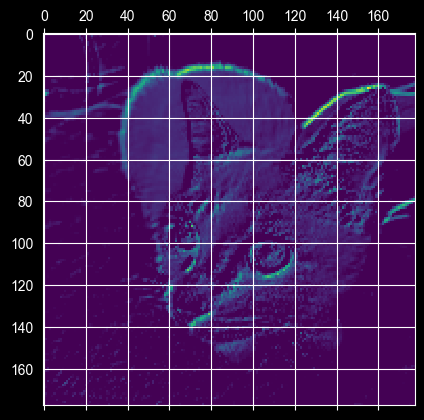

In [17]:
plt.matshow(first_layer_activation[0, :, :, 2], cmap="viridis")

In [ ]:
images_per_row = 16
for layer_name, layer_activation in zip(layer_names, activations):
    n_features = layer_activation.shape[-1]
    size = layer_activation.shape[1]
    n_cols = n_features // images_per_row
    display_grid = np.zeros(
        ((size + 1) * n_cols - 1, images_per_row * (size + 1) - 1)
    )
    for col in range(n_cols):
        for row in range(images_per_row):
            channel_index = col * images_per_row + row
            channel_image = layer_activation[0, :, :, channel_index].copy()
            if channel_image.sum() != 0:
                channel_image -= channel_image.mean()
                channel_image /= channel_image.std()
                channel_image *= 64
                channel_image += 128
            channel_image = np.clip(channel_image, 0, 255).astype("uint8")
            display_grid[
                col * (size + 1) : (col + 1) * size + col,
                row * (size + 1) : (row + 1) * size + row,
            ] = channel_image
    scale = 1.0 / size
    plt.figure(
        figsize=(scale * display_grid.shape[1], scale * display_grid.shape[0])
    )
    plt.title(layer_name)
    plt.grid(False)
    plt.axis("off")
    plt.imshow(display_grid, aspect="auto", cmap="viridis")